<a href="https://colab.research.google.com/github/citraayuningp/CitraAyuning161/blob/main/uts_datmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Citra Ayuning Pramesti
NIM  : 2304020161

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

# Membaca data training
df_train = pd.read_csv('data_training.csv')
print(f"\nData Training: {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"Kolom dalam data training: {df_train.columns.tolist()}")


Data Training: 857 baris, 13 kolom
Kolom dalam data training: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [ ]:
# Membaca data testing
df_test = pd.read_csv('data_testing.csv')
print(f"\nData Testing: {df_test.shape[0]} baris, {df_test.shape[1]} kolom")
print(f"Kolom dalam data testing: {df_test.columns.tolist()}")


Data Testing: 286 baris, 12 kolom
Kolom dalam data testing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [ ]:
df_train = pd.read_csv('data_training.csv')
df_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [ ]:
# Cek 5 baris pertama data training
print("\n5 baris pertama data training:")
print(df_train.head())


5 baris pertama data training:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8        5  1366 

In [ ]:
# Cek informasi data training
print("\nInformasi data training:")
print(df_train.info())



Informasi data training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


In [ ]:
# Cek missing values
print("\nCek missing values pada data training:")
print(df_train.isnull().sum())
print("\nCek missing values pada data testing:")
print(df_test.isnull().sum())



Cek missing values pada data training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Cek missing values pada data testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


In [ ]:
# Cek duplikasi
print(f"\nJumlah data duplikat pada training: {df_train.duplicated().sum()}")
print(f"Jumlah data duplikat pada testing: {df_test.duplicated().sum()}")


Jumlah data duplikat pada training: 0
Jumlah data duplikat pada testing: 0


In [ ]:
# Hapus kolom 'Id' dari data training untuk modeling, tapi simpan untuk identifikasi
X = df_train.drop(['quality', 'Id'], axis=1)
y = df_train['quality']

In [ ]:
# Untuk data testing, simpan Id untuk output
test_ids = df_test['Id']
X_test = df_test.drop('Id', axis=1)

print(f"\nFitur-fitur yang digunakan: {X.columns.tolist()}")


Fitur-fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
# Cek distribusi target variable
print("\nDistribusi nilai quality pada data training:")
print(y.value_counts().sort_index())


Distribusi nilai quality pada data training:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


EKSPLORASI DATA TRAINING

1. Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

2. Statistik Deskriptif:

3. 

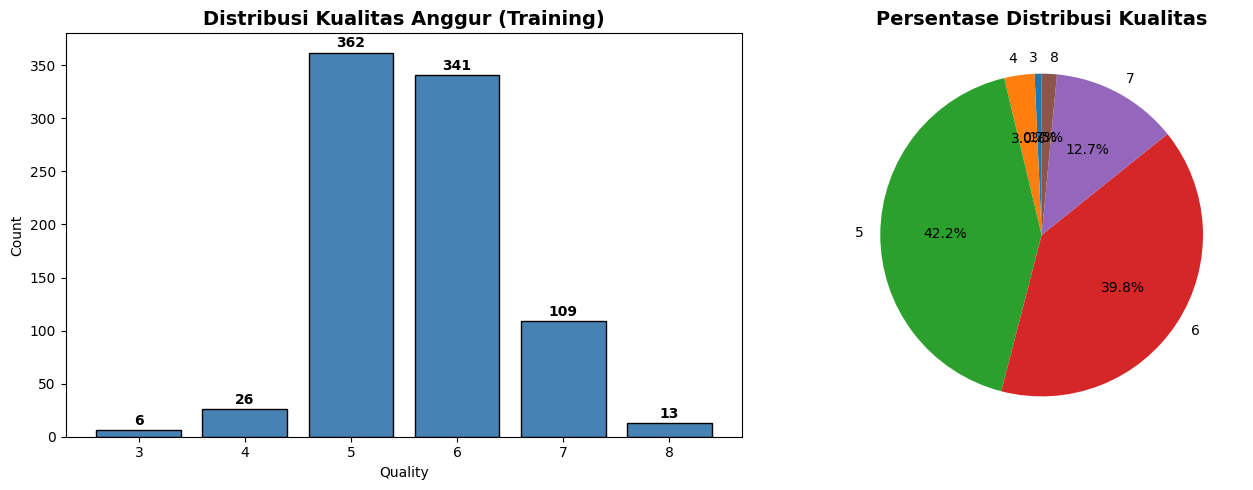


5. Statistik Target:
  - Minimum quality: 3
  - Maximum quality: 8
  - Mean quality: 5.65
  - Median quality: 6.0


In [ ]:
# Eksplorasi Data Training
print("="*60)
print("EKSPLORASI DATA TRAINING")
print("="*60)

print("\n1. Informasi Dataset:")
df_train.info()

print("\n2. Statistik Deskriptif:")
df_train.describe()

print("\n3. Cek Missing Values:")
missing_values = df_train.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Tidak ada missing values!")

print("\n4. Distribusi Variabel Target (Quality):")
quality_dist = df_train['quality'].value_counts().sort_index()
print(quality_dist)

# Visualisasi distribusi quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(quality_dist.index, quality_dist.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Kualitas Anggur (Training)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
for i, v in enumerate(quality_dist.values):
    axes[0].text(quality_dist.index[i], v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(quality_dist.values, labels=quality_dist.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Persentase Distribusi Kualitas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n5. Statistik Target:")
print(f"  - Minimum quality: {df_train['quality'].min()}")
print(f"  - Maximum quality: {df_train['quality'].max()}")
print(f"  - Mean quality: {df_train['quality'].mean():.2f}")
print(f"  - Median quality: {df_train['quality'].median()}")

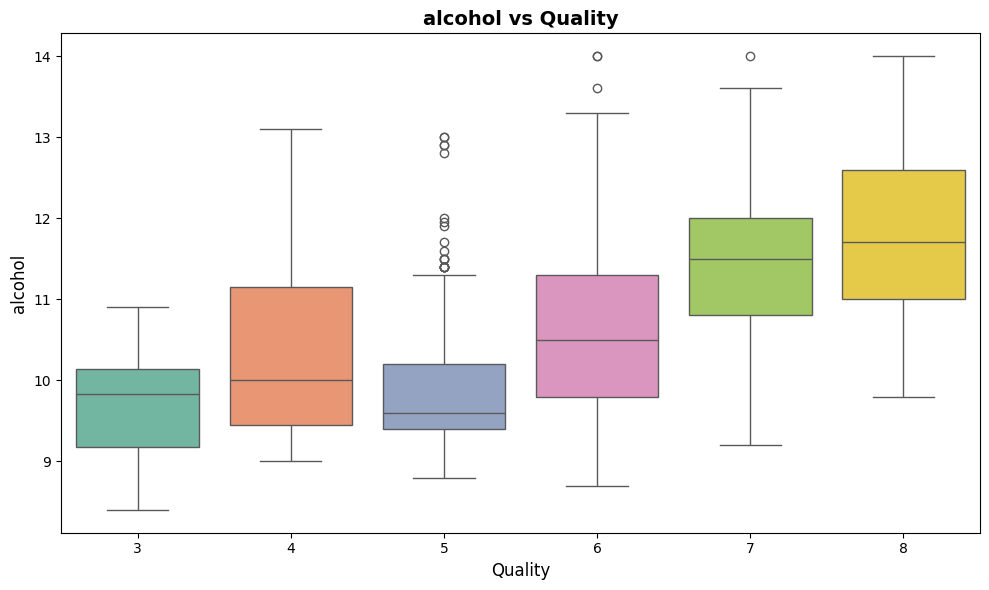

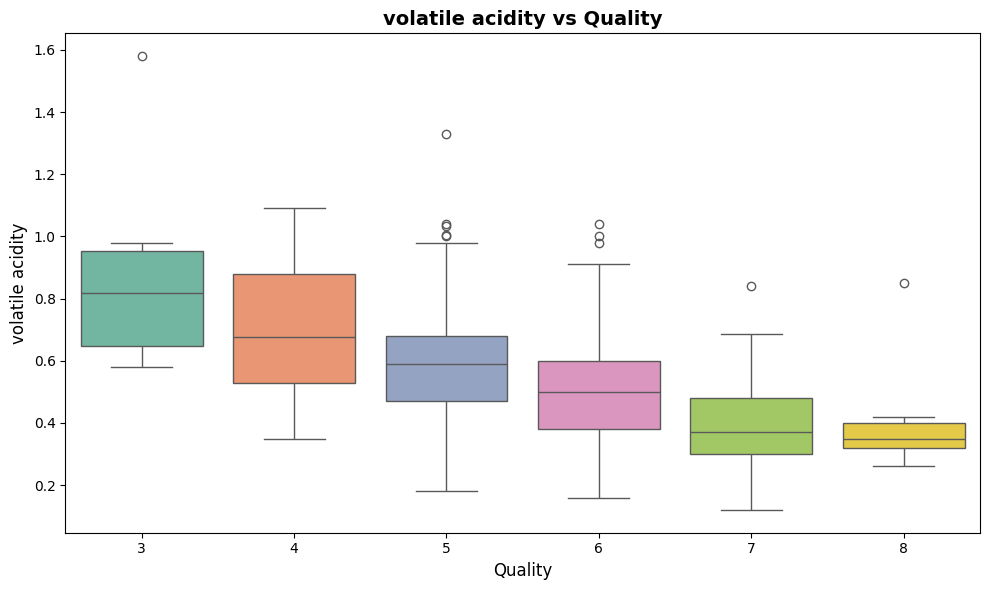

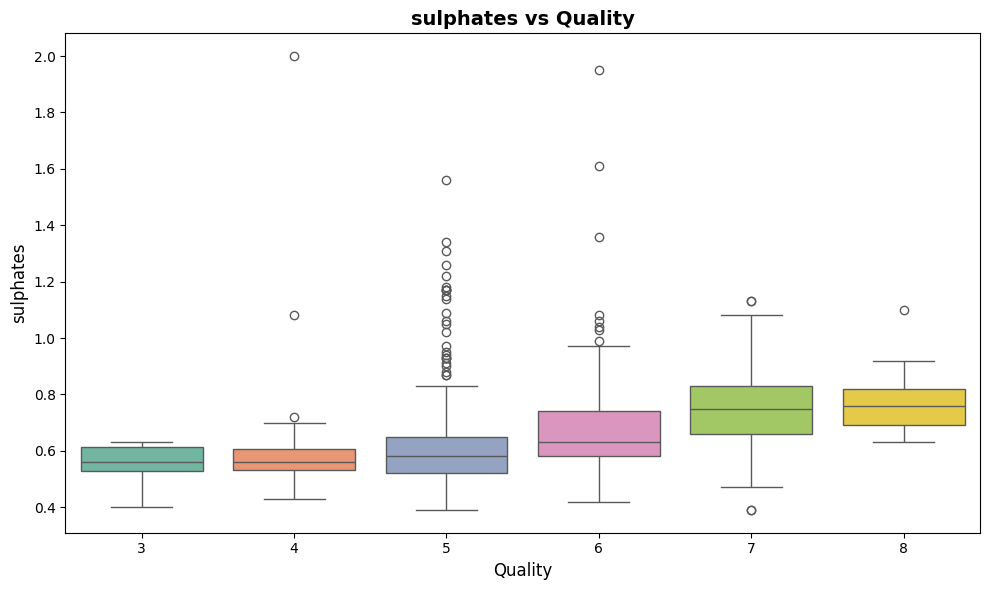

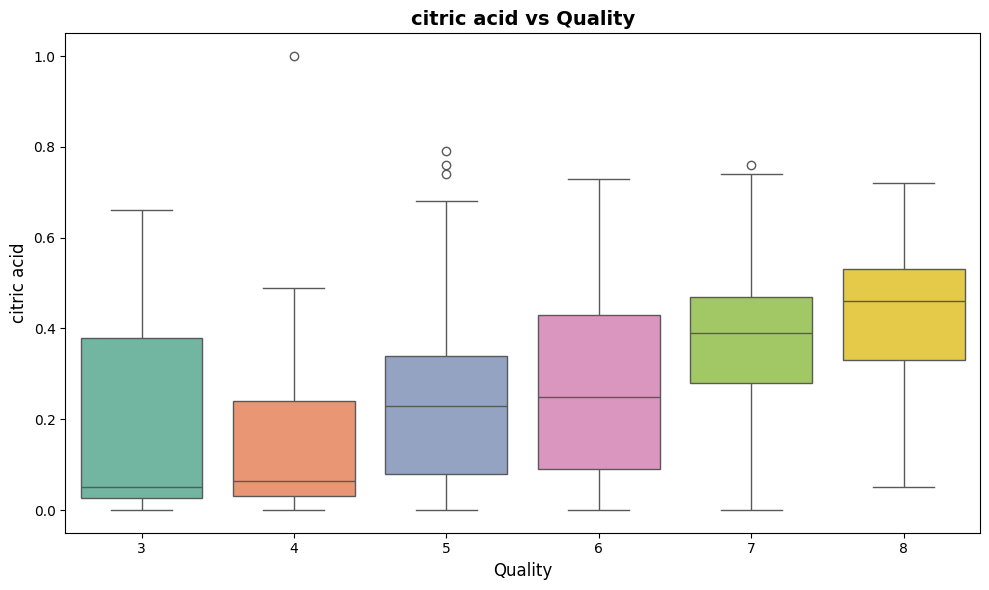

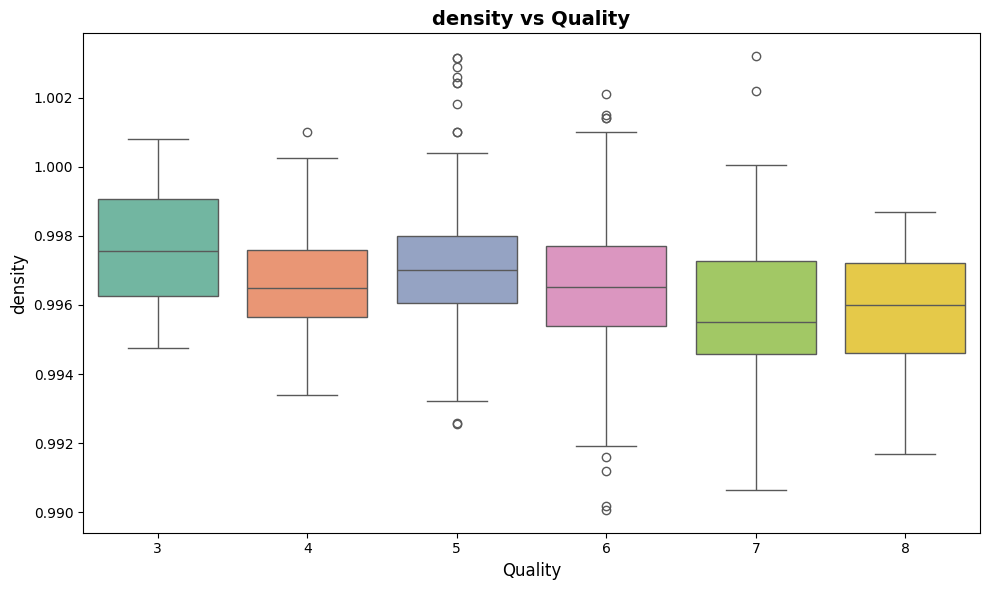

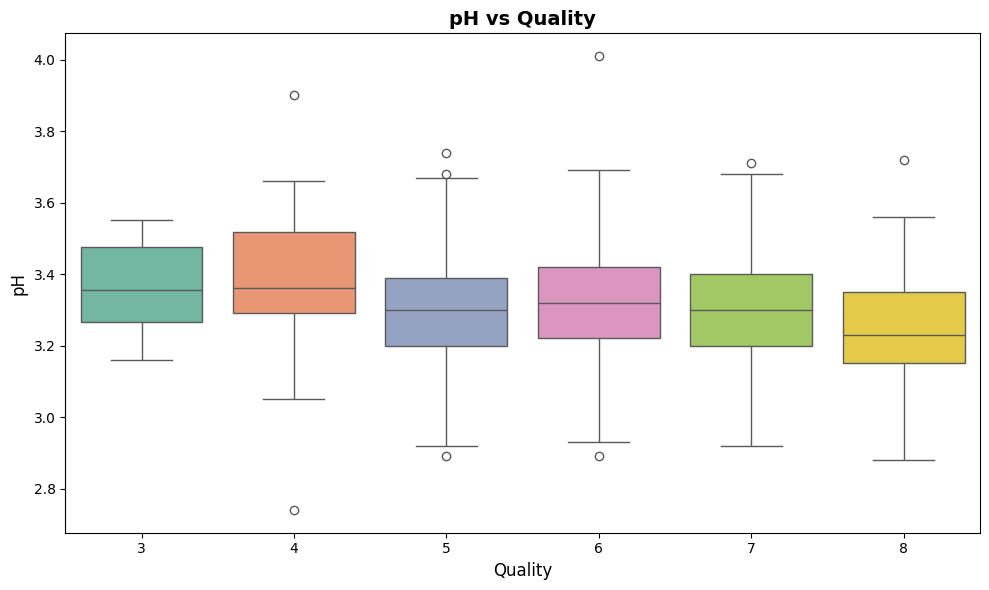

In [ ]:
# Membuat boxplot untuk setiap fitur
for feature in important_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_train, x='quality', y=feature, palette='Set2')
    plt.title(f'{feature} vs Quality', fontsize=14, fontweight='bold')
    plt.xlabel('Quality', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.tight_layout()
    plt.show()

VISUALISASI FITUR TERHADAP TARGET


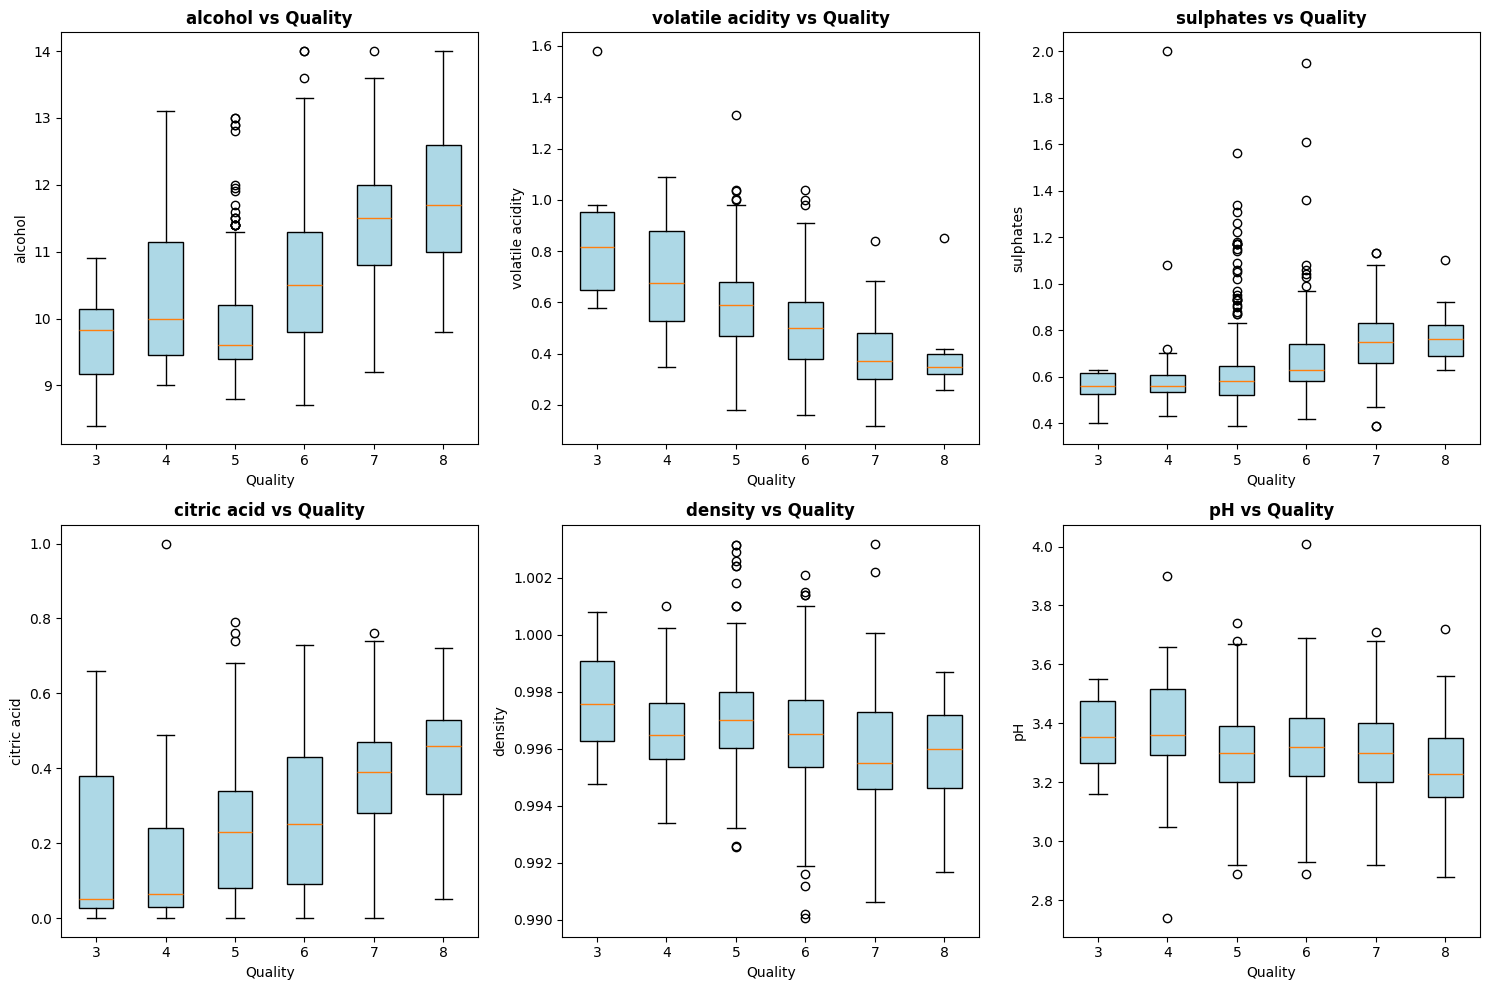

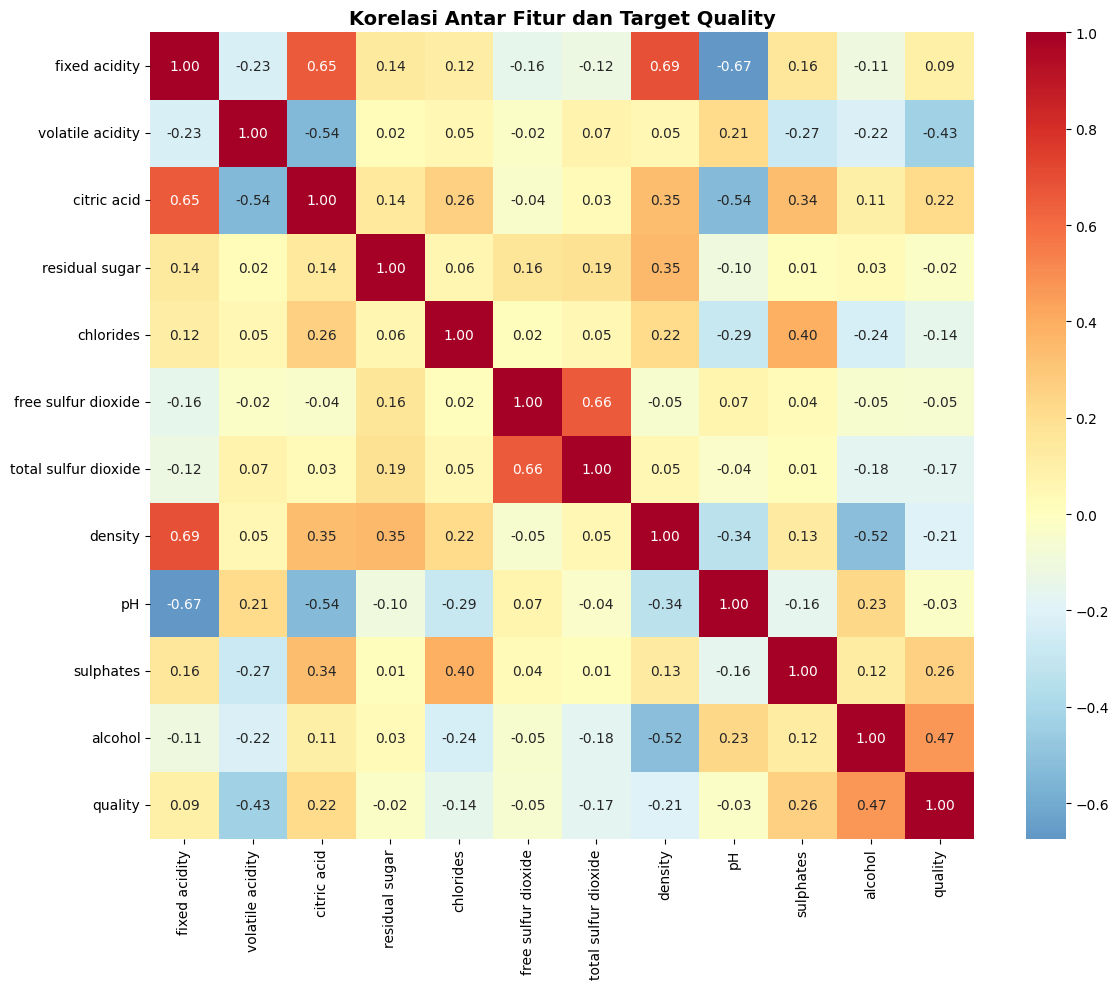


Korelasi setiap fitur dengan Quality:
quality                 1.000000
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [ ]:
print("="*60)
print("VISUALISASI FITUR TERHADAP TARGET")
print("="*60)

# Pilih beberapa fitur penting untuk divisualisasikan
important_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'pH']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    # Boxplot untuk setiap quality
    data_to_plot = [df_train[df_train['quality'] == q][feature].dropna() for q in sorted(df_train['quality'].unique())]
    bp = axes[idx].boxplot(data_to_plot, labels=sorted(df_train['quality'].unique()), patch_artist=True)
    axes[idx].set_title(f'{feature} vs Quality', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Quality')
    axes[idx].set_ylabel(feature)
    # Warna boxplot
    for box in bp['boxes']:
        box.set_facecolor('lightblue')

plt.tight_layout()
plt.show()

# Korelasi antar fitur
plt.figure(figsize=(12, 10))
feature_cols = [col for col in df_train.columns if col not in ['Id', 'quality']]
correlation_matrix = df_train[feature_cols + ['quality']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Korelasi Antar Fitur dan Target Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
corr_with_target = correlation_matrix['quality'].sort_values(ascending=False)
print("\nKorelasi setiap fitur dengan Quality:")
print(corr_with_target)

In [ ]:
# Cek statistik deskriptif
print("\nStatistik deskriptif fitur-fitur:")
print(X.describe())


Statistik deskriptif fitur-fitur:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     857.000000        857.000000   857.000000      857.000000   
mean        8.261960          0.529393     0.267351        2.506184   
std         1.701992          0.179162     0.195144        1.293512   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.395000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.600000          1.580000     1.000000       15.500000   

        chlorides  free sulfur dioxide  total sulfur dioxide     density  \
count  857.000000           857.000000            857.000000  857.000000   
mean     0.086830            15.782964             45.978413    0.996692   
std      0.048721            10.300402             31.692113    0.001901   
min      0.012000    

In [ ]:
# Melakukan standardisasi fitur
scaler = StandardScaler()

# Fit scaler pada data training
X_scaled = scaler.fit_transform(X)

# Transform data testing
X_test_scaled = scaler.transform(X_test)

print("Feature scaling telah dilakukan menggunakan StandardScaler")
print(f"Rata-rata setelah scaling (seharusnya mendekati 0): {X_scaled.mean(axis=0)[:5]}")
print(f"Standar deviasi setelah scaling (seharusnya mendekati 1): {X_scaled.std(axis=0)[:5]}")

Feature scaling telah dilakukan menggunakan StandardScaler
Rata-rata setelah scaling (seharusnya mendekati 0): [ 2.92259410e-16 -2.28003795e-16  1.05710850e-16 -8.29104709e-17
  2.25931033e-16]
Standar deviasi setelah scaling (seharusnya mendekati 1): [1. 1. 1. 1. 1.]


In [ ]:
# Definisi model-model yang akan dicoba
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

In [ ]:
# Evaluasi setiap model dengan cross-validation
print("\nEvaluasi model dengan cross-validation (5-fold):")
results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    print(f"{name:25} -> Akurasi: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Evaluasi model dengan cross-validation (5-fold):
Random Forest             -> Akurasi: 0.6382 (+/- 0.0390)
Gradient Boosting         -> Akurasi: 0.5997 (+/- 0.0284)
Logistic Regression       -> Akurasi: 0.5904 (+/- 0.0314)
SVM                       -> Akurasi: 0.6056 (+/- 0.0252)
KNN                       -> Akurasi: 0.5414 (+/- 0.0309)


In [ ]:
# Training dan evaluasi pada validation set
print("\n" + "-"*60)
print("Evaluasi pada validation set:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    print(f"{name:25} -> Akurasi validation: {accuracy:.4f}")
    print(f"  Classification Report:\n{classification_report(y_val, y_pred, zero_division=0)}")
    print("-"*40)


------------------------------------------------------------
Evaluasi pada validation set:
Random Forest             -> Akurasi validation: 0.6279
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.82      0.74        73
           6       0.59      0.57      0.58        68
           7       0.50      0.36      0.42        22
           8       1.00      0.33      0.50         3

    accuracy                           0.63       172
   macro avg       0.46      0.35      0.37       172
weighted avg       0.60      0.63      0.61       172

----------------------------------------
Gradient Boosting         -> Akurasi validation: 0.6221
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.20      0.25         5

In [ ]:
# Memilih Random Forest sebagai model terbaik (biasanya performa bagus untuk data seperti ini)
print("Melakukan hyperparameter tuning untuk Random Forest...")

# Parameter grid untuk Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_scaled, y)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Melakukan hyperparameter tuning untuk Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.6522


In [ ]:
# Model terbaik
best_model = grid_search.best_estimator_

# Train model terbaik pada seluruh data training
best_model.fit(X_scaled, y)

RandomForestClassifier(max_depth=15, min_samples_split=5, random_state=42)

In [ ]:
# Evaluasi model terbaik dengan cross-validation
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"\nFinal model cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Final model cross-validation accuracy: 0.6522 (+/- 0.0402)


In [ ]:
# Melakukan prediksi pada data testing
predictions = best_model.predict(X_test_scaled)

# Membuat dataframe hasil prediksi
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': predictions
})

print(f"\nHasil prediksi (5 baris pertama):")
print(submission.head())

print(f"\nDistribusi hasil prediksi:")
print(submission['quality'].value_counts().sort_index())


Hasil prediksi (5 baris pertama):
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5

Distribusi hasil prediksi:
quality
5    130
6    129
7     27
Name: count, dtype: int64


In [ ]:
# Untuk Random Forest, kita bisa lihat feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nFeature importance:")
    print(feature_importance)


Feature importance:
                 feature  importance
10               alcohol    0.149951
9              sulphates    0.121568
1       volatile acidity    0.116997
6   total sulfur dioxide    0.094541
7                density    0.088352
4              chlorides    0.085648
2            citric acid    0.074537
0          fixed acidity    0.071768
8                     pH    0.068185
3         residual sugar    0.064904
5    free sulfur dioxide    0.063549


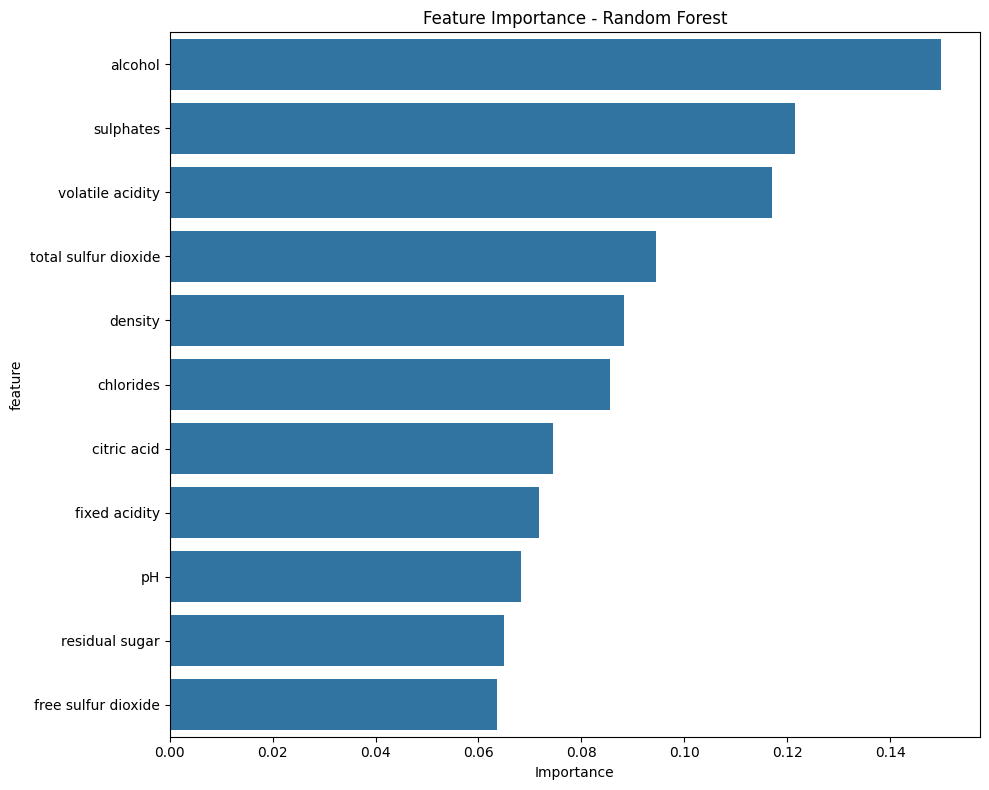

In [ ]:
# Visualisasi feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

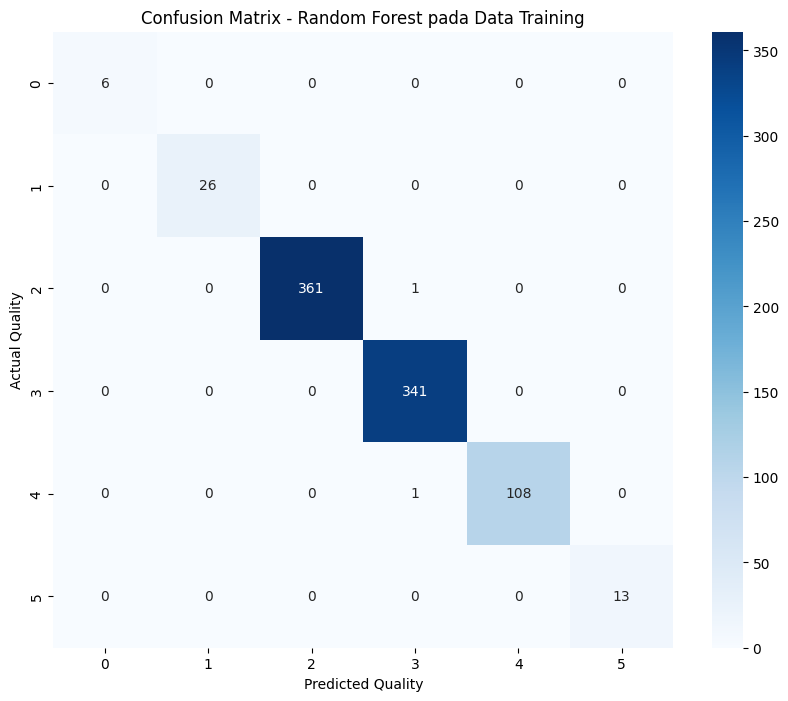

In [ ]:
y_train_pred = best_model.predict(X_scaled)
cm = confusion_matrix(y, y_train_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest pada Data Training')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()




Distribusi Hasil Prediksi (Testing):
quality
5    134
6    122
7     30
Name: count, dtype: int64


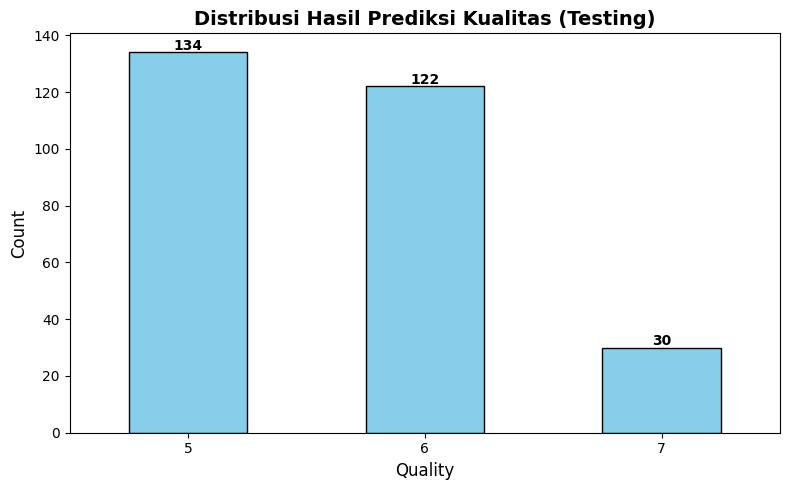

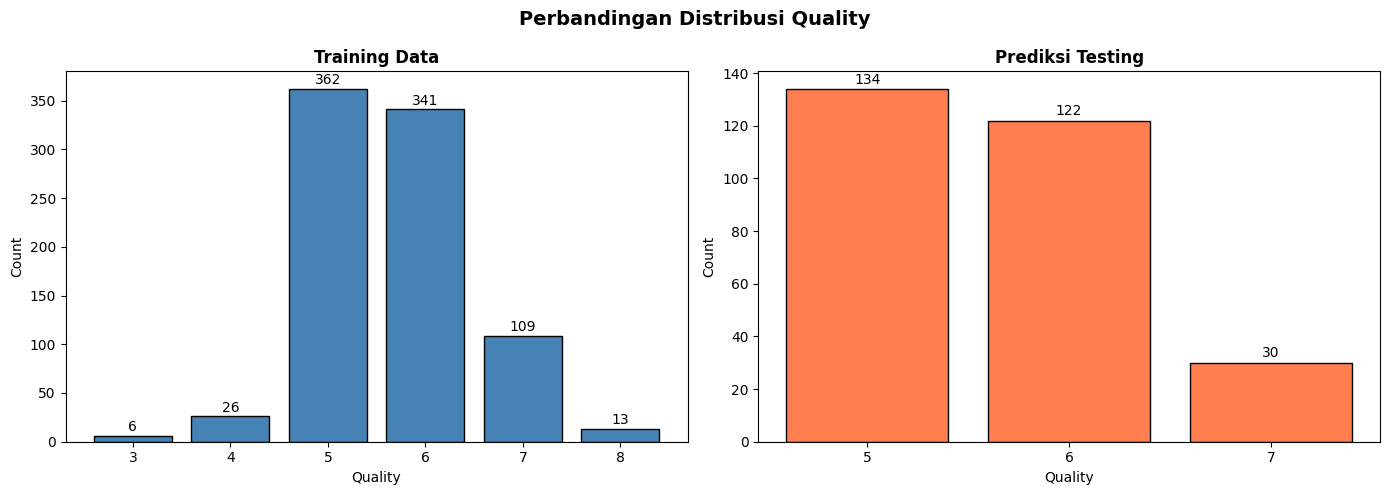


=== Ringkasan Distribusi ===
Training: {3: np.int64(6), 4: np.int64(26), 5: np.int64(362), 6: np.int64(341), 7: np.int64(109), 8: np.int64(13)}
Testing (Prediksi): {5: np.int64(134), 6: np.int64(122), 7: np.int64(30)}


In [ ]:
# ============================================
# DISTRIBUSI HASIL PREDIKSI (TESTING)
# ============================================

# Baca data training dan testing
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

# Pisahkan fitur dan target
X = df_train.drop(['quality', 'Id'], axis=1)
y = df_train['quality']
test_ids = df_test['Id']
X_test = df_test.drop('Id', axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Training model
model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model.fit(X_scaled, y)

# Prediksi
predictions = model.predict(X_test_scaled)

# Buat submission
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': predictions
})

# ============================================
# 1. DISTRIBUSI HASIL PREDIKSI TESTING
# ============================================
print("\nDistribusi Hasil Prediksi (Testing):")
print(submission['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
ax = submission['quality'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribusi Hasil Prediksi Kualitas (Testing)', fontsize=14, fontweight='bold')
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(submission['quality'].value_counts().sort_index().values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. PERBANDINGAN TRAINING VS TESTING
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
train_dist = df_train['quality'].value_counts().sort_index()
axes[0].bar(train_dist.index.astype(str), train_dist.values, color='steelblue', edgecolor='black')
axes[0].set_title('Training Data', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_dist.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Prediksi testing
test_dist = submission['quality'].value_counts().sort_index()
axes[1].bar(test_dist.index.astype(str), test_dist.values, color='coral', edgecolor='black')
axes[1].set_title('Prediksi Testing', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_dist.values):
    axes[1].text(i, v + 2, str(v), ha='center')

plt.suptitle('Perbandingan Distribusi Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 3. RINGKASAN
# ============================================
print("\n=== Ringkasan Distribusi ===")
print(f"Training: {dict(train_dist)}")
print(f"Testing (Prediksi): {dict(test_dist)}")



In [ ]:
# Hitung akurasi pada data training
train_accuracy = accuracy_score(y, y_train_pred)
print(f"\nAkurasi pada data training: {train_accuracy:.4f}")

print("\n" + "="*60)
print("9. RINGKASAN MODEL")
print("="*60)

print(f"""
=== RINGKASAN HASIL ANALISIS ===

1. Data Training: {len(df_train)} sampel dengan {len(X.columns)} fitur
2. Data Testing: {len(df_test)} sampel

3. Model Terbaik: {type(best_model).__name__}
   - Hyperparameters: {grid_search.best_params_}
   - Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})

4. Fitur paling penting:
   {feature_importance.head(3).to_string(index=False) if 'feature_importance' in dir() else 'Tidak tersedia'}

5. Hasil prediksi tersimpan dalam file: hasilprediksi_xxx.csv

6. Metrik evaluasi yang digunakan:
   - Akurasi
   - Classification Report
   - Confusion Matrix
   - Cross-validation (5-fold)
""")


Akurasi pada data training: 0.9977

9. RINGKASAN MODEL

=== RINGKASAN HASIL ANALISIS ===

1. Data Training: 857 sampel dengan 11 fitur
2. Data Testing: 286 sampel

3. Model Terbaik: RandomForestClassifier
   - Hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
   - Cross-validation Accuracy: 0.6522 (+/- 0.0402)

4. Fitur paling penting:
            feature  importance
         alcohol    0.149951
       sulphates    0.121568
volatile acidity    0.116997
      
5. Hasil prediksi tersimpan dalam file: hasilprediksi_xxx.csv

6. Metrik evaluasi yang digunakan:
   - Akurasi
   - Classification Report
   - Confusion Matrix
   - Cross-validation (5-fold)



In [ ]:
submission.to_csv('hasilprediksi_149.csv', index=False)
df = pd.read_csv('hasilprediksi_149.csv')
df

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5
